## **Key topics:**
##### Part 1. Manually Gradient and Hessian Computation
1. sigmoid(x)
2. compute_gradient(y_true, y_pred)
3. compute_hessian(y_pred)
4. compute_gain(gradients, hessians, feature_values, threshold, lambda_reg=1.0)

##### Part 2. Setup Iris Data
1. Prepare_irris_data()

##### Part 3. Manual Split Evaluation

##### Part 4. XGBoost Training and Inspection

##### Part 5: Visualization

##### Main: Run Analysis


#
## **Workflow:**

### Import Packages

In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

### Functions: sigmoid; gradient; hessian

In [20]:
def sigmoid(x):
    """Sigmoid funciton: σ(x) = 1 / (1 + e^-x)"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500))) # np.clip(x, -500, 500) prvent to overflow

In [21]:
def compute_gradient(y_true, y_pred):
    """
    Compute gradient for binary logistic loss
    g = σ(ŷ) - y
    
    Arg:
        y_true: Binary labels[0, 1]
        y_pred: Raw predictions (log-odds)
    Returns:
        gradients: Array of first derivatives
    """
    sigma = sigmoid(y_pred)
    g = sigma - y_true
    return g

In [22]:
def compute_hessian(y_pred):
    """
    Compute Hessian for binary logistic loss

    h = σ(ŷ) * (1 - σ(ŷ))

    Args:
        y_pred: Raw predictions (log-odds)
    
    Returns:
        hessians: Array of second derivatives
    """

    sigma = sigmoid(y_pred)
    h = sigma * (1 - sigma)
    return h

In [106]:
def compute_gain(gradients, hessians, feature_values, threshold, lambda_reg=1.0):
    """
    Compute gain for a candiate split
    Gain = (G_L² / (H_L + λ)) + (G_R² / (H_R + λ)) - (G² / (H + λ))
    
    Args:
        gradients: Array of gradients for all samples
        hessians: Array of Hessians for all samples
        feature_values: Array of feature values for split evaluation, everytime only apply one feature
        threshold: Split threshold
        lambda_reg: L2 regulation parameter
    
    Returns:
        gain: represent loss reduction from split
        split_info: Dict with detailed split statistics

    """

   
    # Partition by threshold
    left_mask = feature_values < threshold
    right_mask = ~left_mask
    
    # Check for valid split (both sides non-empty)
    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return -np.inf, None
    
    # Aggregate statistics
    G_L = gradients[left_mask].sum()
    H_L = hessians[left_mask].sum()
    G_R = gradients[right_mask].sum()
    H_R = hessians[right_mask].sum()
    G_total = gradients.sum()
    H_total = hessians.sum()
    
    # Compute gain
    gain = (
        (G_L ** 2) / (H_L + lambda_reg) +
        (G_R ** 2) / (H_R + lambda_reg) -
        (G_total ** 2) / (H_total + lambda_reg)
    )
    
    # Compute optimal leaf weights
    w_L = -G_L / (H_L + lambda_reg)
    w_R = -G_R / (H_R + lambda_reg)
    
    split_info = {
        'G_L': G_L,
        'H_L': H_L,
        'G_R': G_R,
        'H_R': H_R,
        'G_total': G_total,
        'H_total': H_total,
        'w_L': w_L,
        'w_R': w_R,
        'n_left': left_mask.sum(),
        'n_right': right_mask.sum(),
        'gain': gain
    }
    
    return gain, split_info


### Part 2: Setup Iris Data

In [24]:
def prepare_iris_data():
    iris = load_iris()
    X = iris.data[:, :2] # Sepal length, sepal width
    y = (iris.target == 1).astype(int)

    # Train_test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    # Standardize featrues
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return{
        'X_train': X_train,
        'X_test': X_test,
        'X_train_scaled': X_train_scaled,
        'X_test_scaled': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler
    }

### Part 3: Manual Split Evaluation

In [143]:
def manual_split_search(X, y, lambda_reg = 1.0, max_features=None):
    """ 
    Manually search for the best split

    Args:
        X: Feature matrix (n_samples, n_features)
        y: Bineary labels
        lambda_reg: L2 regularization
        max_features: Number of candidate thresholds per feature
        
    Return:
        best_split_info: Dict with best split details
    """

    # Initialize predictions at root (raw score = 0)
    y_pred = np.zeros(len(y))

    # Compute gradients and Hessian at root
    gradients = compute_gradient(y, y_pred)
    hessians = compute_hessian(y_pred)

    best_gain = -np.inf
    best_split_info = None

    n_features = X.shape[1]

    # Grid search over all features and candidate thresholds
    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]

        # Generate candiate thresholds
        if max_features:
            # Sample quantiles
            thresholds = np.percentile(feature_values, np.linspace(10, 90, max_features))
        else:
            # Use all unique values
            thresholds = np.unique(feature_values)

        for threshold in thresholds:
            gain, split_info = compute_gain(
                gradients, hessians, feature_values, threshold, lambda_reg
            )

            if gain > best_gain:
                best_gain = gain
                best_split_info = {
                    'feature_idx': feature_idx,
                    'threshold': threshold,
                    **split_info
                }

    return best_split_info


### Part 4: XGBoost Training and Inspection

In [144]:
def train_gradient_boosting_iris(X_train, y_train, n_estimators=2, max_depth=2):
    """
    Train sklearn GradientBoostingClassifier on Iris data

    Args:
        X_train, y_train: Traing data
        n_estimators: Number of boosting rounds
        max_depth: Maximum tree depth

    Returns:
        model: Trained GradientBoostingClassifier
    """

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate = 0.1,
        random_state=42,
        verbose=0
    )

    model.fit(X_train, y_train)
    return model

In [150]:
def inspect_sklearn_trees(model, feature_names):
    """
    Inspect sklearn trees and extract structure and leaf weights.

    Args:
        model: Trained GradientBoostingClassifier
        feature_names: List fo feature names
    
    Returns:
        DataFrame with tree structure and statistics
    """
    from sklearn.tree import _tree # lower-level C implementation of the Decision Tree algorithms used by scikitlearn

    results = []

    for tree_idx, estimator in enumerate(model.estimators_): # model.estimators_: is the trees used 
        tree = estimator[0].tree_ # first estimator tree

        # return the feature name used to split for each note (maping the index of feature to the feature name)
        # _tree.TREE_UNDEFINED = 0 if the node is a leaf, otherwise would return the index of the feature        
        feature_names = [
            feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined!'
            for i in tree.feature
        ]

        def recurse(node, depth, parent_id):
            indent = " " * depth
            if tree.feature[node] != _tree.TREE_UNDEFINED:
                # Split node
                name = feature_names[node] # the index of the feature used to split the node
                threshold = tree.threshold[node] # the threshold used to split the node
                samples = tree.n_node_samples[node] # samples fall under the node
                value = tree.value[node][0] # sum of the weighted samples for each class at the node. 

                results.append({
                    'tree': tree_idx,
                    'node_id': node,
                    'depth': depth,
                    'type': 'split',
                    'feature': name,
                    'threshold': threshold,
                    'samples': samples,
                    'value': value,
                    'leaf_weight': None
                })

                # Recurse
                recurse(tree.children_left[node], depth+1, node)
                recurse(tree.children_right[node], depth+1, node)

            else:
                # leaf node
                samples = tree.n_node_samples[node]
                value = tree.value[node][0]

                # for regression outputs in GradientBoosting, value is scalar; this is only for two classes: value[1] for class 1, value[0] for class 0, difference is Net bias toward class 1
                leaf_weight = float(value[0]) if len(value) == 1 else(value[1] - value[0])

                results.append({
                    'tree': tree_idx,
                    'node_id': node,
                    'depth': depth,
                    'type': 'leaf',
                    'feature': None,
                    'threshold': None,
                    'samples': samples,
                    'value': value,
                    'leaf_weight': leaf_weight
                })
        recurse(0, 0, -1)

    return pd.DataFrame(results)
        

### Part 5: Visualization

In [151]:
def plot_split_gains(X, y, feature_names=None):
    """
    Visualize gain across different feature thresholds.
    
    Args:
        X: Feature matrix
        y: Binary labels
        feature_names: List of feature names
    """
    
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(X.shape[1])]
    
    y_pred = np.zeros(len(y))
    gradients = compute_gradient(y, y_pred)
    hessians = compute_hessian(y_pred)
    
    fig, axes = plt.subplots(1, X.shape[1], figsize=(14, 4))
    if X.shape[1] == 1:
        axes = [axes]
    
    for feature_idx, ax in enumerate(axes):
        feature_values = X[:, feature_idx]
        thresholds = np.percentile(feature_values, np.linspace(5, 95, 20))
        gains = []
        
        for threshold in thresholds:
            gain, _ = compute_gain(gradients, hessians, feature_values, threshold)
            gains.append(gain if gain > -np.inf else 0)
        
        ax.plot(thresholds, gains, 'o-', linewidth=2, markersize=6)
        ax.set_xlabel(f'{feature_names[feature_idx]} Threshold')
        ax.set_ylabel('Gain')
        ax.set_title(f'Split Gain vs. {feature_names[feature_idx]}')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    #plt.savefig('/mnt/user-data/outputs/xgboost_iris_gains.png', dpi=150, bbox_inches='tight')
    # print("✓ Saved gain visualization to xgboost_iris_gains.png")
    # plt.close()

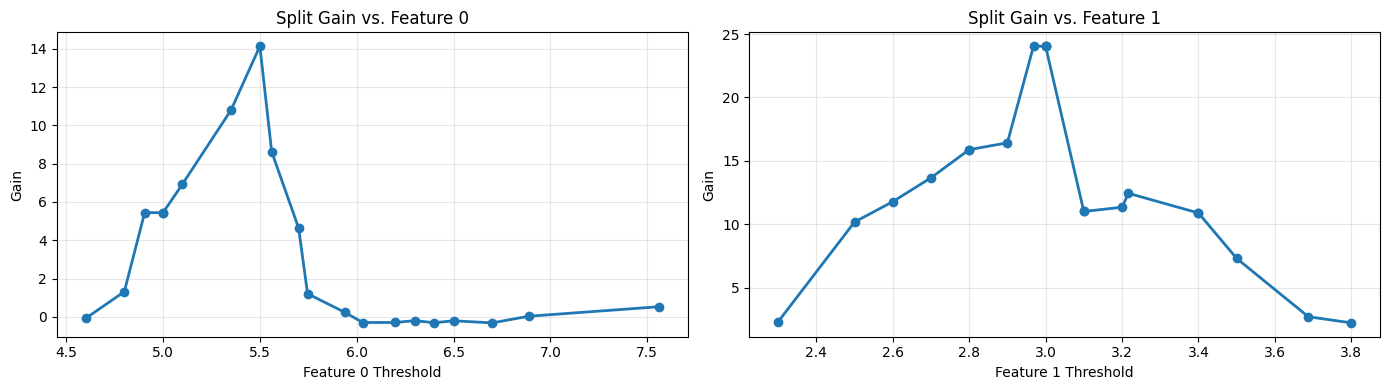

In [152]:
# load the data
data = prepare_iris_data()
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

# plot the gain by feature and different thresholds
plot_split_gains(X_train, y_train)

In [175]:
def main():
    print("=" * 80)
    print("XGBoost Gradient, Hessian, and Gain Calculations with Iris")
    print("=" * 80)
    
    # Load data
    print("\n[1] Loading Iris data (binary classification: versicolor vs. rest)...")
    data = prepare_iris_data()
    X_train, y_train = data['X_train_scaled'], data['y_train']
    X_test, y_test = data['X_test_scaled'], data['y_test']
    feature_names = ['Sepal Length', 'Sepal Width']
    
    print(f"    Training samples: {len(X_train)}")
    print(f"    Class distribution: {np.bincount(y_train)}")
    
    # Manual split search
    print("\n[2] Manual split search (brute force)...")
    best_split = manual_split_search(X_train, y_train, lambda_reg=1.0, max_features=10)
    
    print(f"\n    Best split found:")
    print(f"      Feature: {feature_names[best_split['feature_idx']]}")
    print(f"      Threshold: {best_split['threshold']:.4f}")
    print(f"      Gain: {best_split['gain']:.4f}")
    print(f"      Left child: G={best_split['G_L']:.4f}, H={best_split['H_L']:.4f}, "
          f"w={best_split['w_L']:.4f}, n={best_split['n_left']}")
    print(f"      Right child: G={best_split['G_R']:.4f}, H={best_split['H_R']:.4f}, "
          f"w={best_split['w_R']:.4f}, n={best_split['n_right']}")
    
    # Train Gradient Boosting
    print("\n[3] Training sklearn GradientBoostingClassifier (2 estimators, max_depth=2)...")
    model = train_gradient_boosting_iris(X_train, y_train, n_estimators=2, max_depth=2)
    print("    ✓ Model trained")
    
    # Inspect trees
    print("\n[4] Inspecting decision trees...")
    tree_info = inspect_sklearn_trees(model, feature_names)
    print("\n    Tree structure (first 15 nodes):")
    print(tree_info.head(15).to_string(index=False))
    
    # Training and test performance
    print("\n[5] Model performance:")
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print(f"    Training accuracy: {train_score:.4f}")
    print(f"    Test accuracy: {test_score:.4f}")
    
    # Feature importance
    print("\n[6] Feature importance:")
    importances = model.feature_importances_
    for feat_idx, imp in enumerate(importances):
        print(f"    {feature_names[feat_idx]}: {imp:.4f}")
    
    # Visualization
    print("\n[7] Generating visualizations...")
    plot_split_gains(X_train, y_train, feature_names)
    
    print("\n" + "=" * 80)
    print("Analysis complete! Check outputs for visualizations.")
    print("=" * 80)

XGBoost Gradient, Hessian, and Gain Calculations with Iris

[1] Loading Iris data (binary classification: versicolor vs. rest)...
    Training samples: 105
    Class distribution: [70 35]

[2] Manual split search (brute force)...

    Best split found:
      Feature: Sepal Width
      Threshold: -0.1318
      Gain: 24.0487
      Left child: G=-6.0000, H=10.0000, w=0.5455, n=40
      Right child: G=23.5000, H=16.2500, w=-1.3623, n=65

[3] Training sklearn GradientBoostingClassifier (2 estimators, max_depth=2)...
    ✓ Model trained

[4] Inspecting decision trees...

    Tree structure (first 15 nodes):
 tree  node_id  depth  type      feature  threshold  samples                     value  leaf_weight
    0        0      0 split  Sepal Width  -0.243410      105 [-1.3745618400120986e-17]          NaN
    0        1      1 split Sepal Length   0.413520       40     [0.31666666666666643]          NaN
    0        2      2  leaf         None        NaN       25      [2.2799999999999994]     

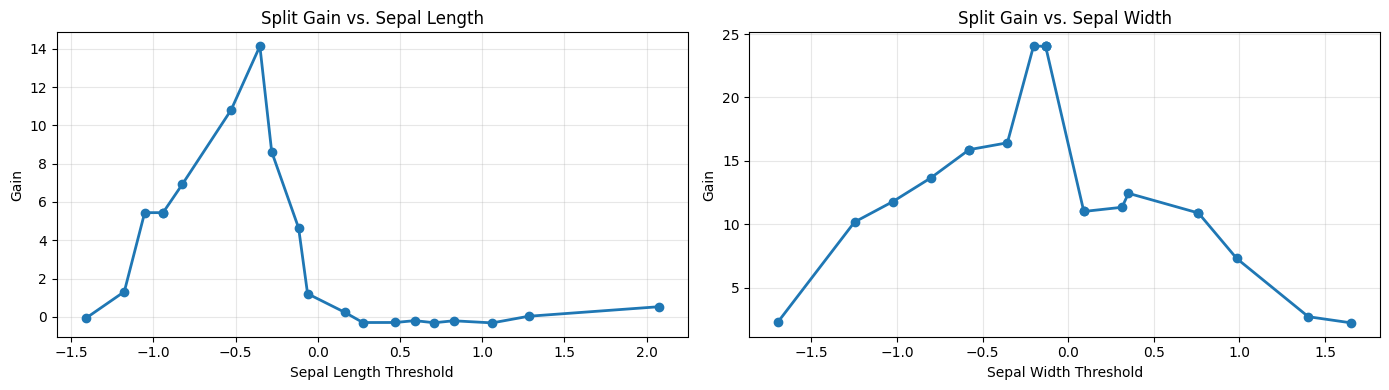

In [176]:
main()